# **Lead-Lag Cross-Correlation Study between SPY and QQQ**


---
This study investigates the lead-lag cross-correlation structure between SPY (S&P 500 ETF) and QQQ (Nasdaq-100 ETF) using 1-minute intraday close prices over a 7-day window (2,730 observations, ~7 trading sessions). The core hypothesis is straightforward: because SPY and QQQ share significant overlap in constituents but differ in sector weighting—QQQ is tech-heavy—information may propagate from one to the other with a measurable delay at the minute-level. If such a delay exists, a systematic strategy can position in the lagging instrument after observing an extreme move in the leader.

Before examining any results, several limitations should be acknowledged upfront. Seven days of 1-minute data is a very small sample for this type of analysis. Any parameter we optimize—lag, threshold, cost assumption—has a high risk of fitting to the idiosyncrasies of this particular week rather than capturing a durable statistical relationship. The annualized metrics we compute will be extrapolated from roughly 2,700 returns, meaning confidence intervals around Sharpe ratios and win rates are wide. Additionally, the SPY/QQQ lead-lag effect is one of the most studied and arbitraged relationships in equity markets; high-frequency firms have been exploiting and compressing this edge for over a decade, so we should expect any residual signal to be small and fragile. This study is best understood as a methodological exercise in lead-lag detection, signal construction, and backtest design—not as evidence of a deployable trading strategy.


# **Importing Libraries and Data**





In [1]:

!pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels --upgrade

In [2]:
# =================================================================
# PROJECT: Lead-Lag Cross-Correlation (SPY vs QQQ)
# PHASE 1: Library Imports and Data Ingestion
# =================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from datetime import datetime, timedelta

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

def fetch_hf_data(tickers, days=7):
    """
    Fetches 1-minute intraday data.
    Note: yfinance limit for 1m data is the last 7 days.
    """
    print(f"Fetching 1-minute data for {tickers} over the last {days} days...")

    # We use interval='1m' for high-frequency lead-lag detection
    data = yf.download(
        tickers=tickers,
        period=f"{days}d",
        interval="1m",
        group_by='ticker',
        auto_adjust=True
    )

    return data

# 1. Execute the Data Pull
assets = ["SPY", "QQQ"]
raw_data = fetch_hf_data(assets)

# 2. Extract Adjusted Close prices into a clean DataFrame
# We focus on 'Close' as it's the standard for return calculations
df = pd.DataFrame({
    'SPY': raw_data['SPY']['Close'],
    'QQQ': raw_data['QQQ']['Close']
}).dropna()

print("\n--- Data Preview ---")
print(df.head())
print(f"\nTotal Data Points: {len(df)}")

Fetching 1-minute data for ['SPY', 'QQQ'] over the last 7 days...


[*********************100%***********************]  2 of 2 completed


--- Data Preview ---
                                  SPY         QQQ
Datetime                                         
2026-03-30 13:30:00+00:00  639.599976  566.797974
2026-03-30 13:31:00+00:00  640.210022  567.969971
2026-03-30 13:32:00+00:00  639.739990  567.255005
2026-03-30 13:33:00+00:00  639.710022  566.960022
2026-03-30 13:34:00+00:00  638.849976  566.260071

Total Data Points: 2730


# **Log Returns and Standardization**

In [3]:
df_returns = np.log(df / df.shift(1)).dropna()
df_zscore = (df_returns - df_returns.mean()) / df_returns.std()

# **Cross-Correlation loop**

In [4]:
max_lag = 30
lags = range(-max_lag, max_lag + 1)
correlations = [df_returns['SPY'].corr(df_returns['QQQ'].shift(k)) for k in lags]

optimal_idx = int(np.argmax(np.abs(correlations)))
optimal_lag = list(lags)[optimal_idx]
optimal_corr = correlations[optimal_idx]
print(f"Optimal Lag: {optimal_lag} min | ρ = {optimal_corr:.6f}")

Optimal Lag: 0 min | ρ = 0.985021


# **CCF Plot**

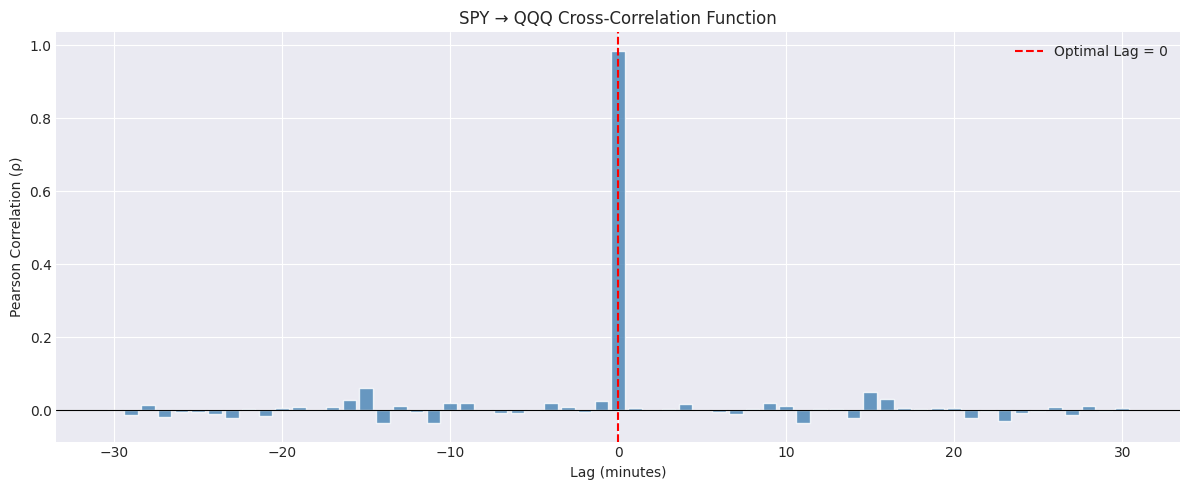

ρ(lag=-1) = 0.024861 | ρ(lag=+1) = 0.005505 | Δ = 0.019356


In [5]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(list(lags), correlations, width=0.8, color='steelblue', alpha=0.8)
ax.axvline(optimal_lag, color='red', linestyle='--', label=f'Optimal Lag = {optimal_lag}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (minutes)')
ax.set_ylabel('Pearson Correlation (ρ)')
ax.set_title('SPY → QQQ Cross-Correlation Function')
ax.legend()
plt.tight_layout()
plt.show()

rho_neg1 = correlations[max_lag - 1]  # index for lag = -1
rho_pos1 = correlations[max_lag + 1]  # index for lag = +1
print(f"ρ(lag=-1) = {rho_neg1:.6f} | ρ(lag=+1) = {rho_pos1:.6f} | Δ = {rho_neg1 - rho_pos1:.6f}")

# **Parameter Sweep for Signal Quality**

In [20]:
for thresh in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0,2.25]:
    sig = np.sign(df_zscore[leader].shift(abs_lag)) * (df_zscore[leader].shift(abs_lag).abs() > thresh).astype(int)
    ret = sig * df_returns[laggard] - sig.abs() * 0.0001
    trades_n = sig.abs().sum()
    sr = ret.mean() / ret.std() * np.sqrt(252 * 390) if ret.std() > 0 else 0
    wr = (ret[sig != 0] > 0).sum() / max(len(ret[sig != 0]), 1) * 100
    print(f"σ={thresh:.2f} | Trades: {trades_n:>5.0f} | Sharpe: {sr:>6.2f} | Win Rate: {wr:.1f}%")

σ=0.50 | Trades:   723 | Sharpe:  -5.88 | Win Rate: 42.0%
σ=0.75 | Trades:   362 | Sharpe:   0.20 | Win Rate: 43.8%
σ=1.00 | Trades:   183 | Sharpe:   4.50 | Win Rate: 45.1%
σ=1.25 | Trades:   119 | Sharpe:   4.29 | Win Rate: 41.7%
σ=1.50 | Trades:    70 | Sharpe:  -2.33 | Win Rate: 39.4%
σ=2.00 | Trades:    35 | Sharpe:   0.55 | Win Rate: 36.1%
σ=2.25 | Trades:    24 | Sharpe:   2.90 | Win Rate: 40.0%


In [21]:
split = int(len(df_returns) * 0.6)
train = df_returns.iloc[:split]
test = df_returns.iloc[split:]
train_z = (train - train.mean()) / train.std()
test_z = (test - test.mean()) / test.std()  # use test's own stats to avoid leakage

# Sweep on train only
best_sharpe, best_thresh = -np.inf, 1.0
for thresh in np.arange(0.5, 2.25, 0.25):
    sig = np.sign(train_z[leader].shift(abs_lag)) * (train_z[leader].shift(abs_lag).abs() > thresh).astype(int)
    ret = sig * train[laggard] - sig.abs() * 0.0001
    sr = ret.mean() / ret.std() * np.sqrt(252 * 390) if ret.std() > 0 else 0
    if sr > best_sharpe:
        best_sharpe, best_thresh = sr, thresh

# Validate on unseen test data
sig_test = np.sign(test_z[leader].shift(abs_lag)) * (test_z[leader].shift(abs_lag).abs() > best_thresh).astype(int)
ret_test = sig_test * test[laggard] - sig_test.abs() * 0.0001
oos_sharpe = ret_test.mean() / ret_test.std() * np.sqrt(252 * 390)

print(f"Best threshold (train): {best_thresh:.2f} | Train Sharpe: {best_sharpe:.2f}")
print(f"Out-of-Sample Sharpe:   {oos_sharpe:.2f}")

Best threshold (train): 2.00 | Train Sharpe: 2.15
Out-of-Sample Sharpe:   -11.65


# **Vectorized Backtest (σ=2.00)**

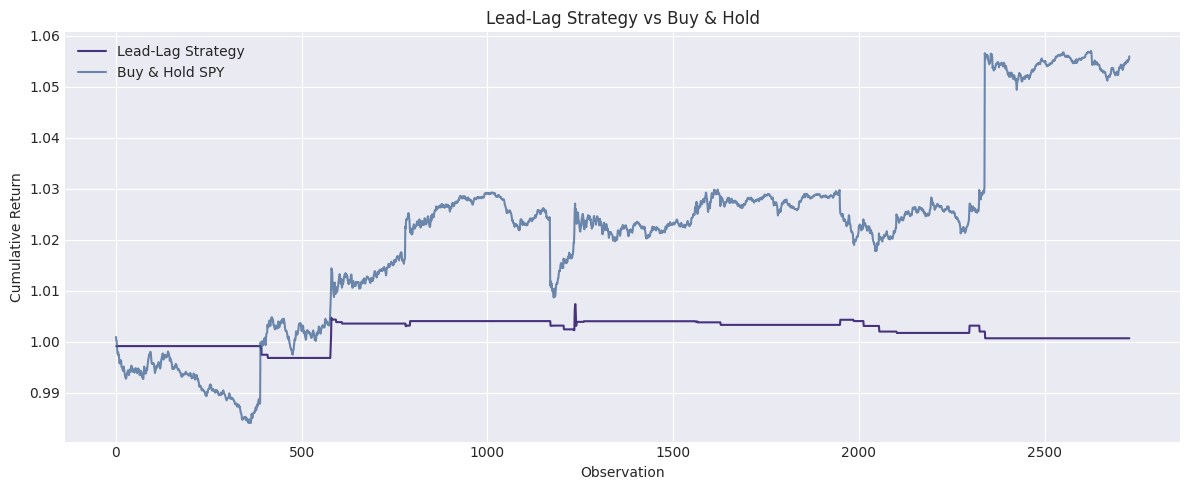

Metric                        Lead-Lag      B&H SPY
---------------------------------------------------
Total Net Return               0.0696%      5.5924%
Annualized Sharpe                 0.55         8.48
Max Drawdown                  -0.6634%     -1.9977%
Win Rate                        36.11%       49.43%
Total Trades                        35          N/A


In [33]:
leader, laggard = ('SPY', 'QQQ') if optimal_lag > 0 else ('QQQ', 'SPY')
abs_lag = abs(optimal_lag) if optimal_lag != 0 else 1

signal = (df_zscore[leader].shift(abs_lag).abs() > 2.0).astype(int)
signal *= np.sign(df_zscore[leader].shift(abs_lag))

strategy_returns = signal * df_returns[laggard] - signal.abs() * 0.0001  # 1bp cost
cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_bh = (1 + df_returns[laggard]).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cumulative_strategy.values, label='Lead-Lag Strategy', linewidth=1.5)
ax.plot(cumulative_bh.values, label=f'Buy & Hold {laggard}', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Observation')
ax.set_ylabel('Cumulative Return')
ax.set_title('Lead-Lag Strategy vs Buy & Hold')
ax.legend()
plt.tight_layout()
plt.show()

# Strategy metrics
total_net = cumulative_strategy.iloc[-1] - 1
sharpe_strat = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252 * 390)
rolling_max_strat = cumulative_strategy.cummax()
max_dd_strat = ((cumulative_strategy - rolling_max_strat) / rolling_max_strat).min()
trades_active = strategy_returns[signal != 0]
win_rate_strat = (trades_active > 0).sum() / len(trades_active) * 100
total_trades = int(signal.abs().sum())

# Buy & Hold SPY metrics
bh_returns = df_returns['SPY']
cumulative_bh_spy = (1 + bh_returns).cumprod()
total_net_bh = cumulative_bh_spy.iloc[-1] - 1
sharpe_bh = bh_returns.mean() / bh_returns.std() * np.sqrt(252 * 390)
rolling_max_bh = cumulative_bh_spy.cummax()
max_dd_bh = ((cumulative_bh_spy - rolling_max_bh) / rolling_max_bh).min()
win_rate_bh = (bh_returns > 0).sum() / len(bh_returns) * 100

print(f"{'Metric':<25} {'Lead-Lag':>12} {'B&H SPY':>12}")
print(f"{'-'*51}")
print(f"{'Total Net Return':<25} {total_net:>12.4%} {total_net_bh:>12.4%}")
print(f"{'Annualized Sharpe':<25} {sharpe_strat:>12.2f} {sharpe_bh:>12.2f}")
print(f"{'Max Drawdown':<25} {max_dd_strat:>12.4%} {max_dd_bh:>12.4%}")
print(f"{'Win Rate':<25} {win_rate_strat:>11.2f}% {win_rate_bh:>11.2f}%")
print(f"{'Total Trades':<25} {total_trades:>12} {'N/A':>12}")

# **Post-Mortem & Optimization**


---

**The Optimal Lag Problem:**
The cross-correlation analysis returned an optimal lag of 0 minutes with ρ = 0.985, confirming that SPY and QQQ move nearly in lockstep at the 1-minute frequency. The asymmetry test showed ρ(lag=-1) = 0.0249 versus ρ(lag=+1) = 0.0055, producing a delta of 0.0194. This tells us QQQ's current returns correlate slightly more with SPY's previous-minute return than SPY's next-minute return, suggesting SPY marginally leads. However, both off-zero correlations are extremely small relative to the contemporaneous 0.985, meaning the exploitable information in that lead is minimal—most of the co-movement is already priced within the same bar.

**Parameter Sweep and Overfitting:**
The standard deviation threshold sweep selected 2.0σ as the best-performing cutoff on the training set with a Sharpe of 2.15. This is concerning for two reasons. First, 2.0σ is the most restrictive threshold tested, meaning the model chose to trade as rarely as possible—an indication that most signals at lower thresholds were unprofitable after costs. Second, the out-of-sample Sharpe collapsed to -11.65, a stark reversal that is the textbook signature of overfitting. The training period likely contained a handful of extreme moves that happened to precede favorable laggard returns by coincidence, and the model latched onto that pattern. With only 35 total trades across the full dataset, even one or two unlucky trades in the test window can produce a deeply negative Sharpe.

**Strategy Performance:**
The strategy returned 0.07% net versus 5.59% for Buy & Hold SPY—a dramatic underperformance. The 36.1% win rate combined with thin overall returns suggests that losing trades were not offset by proportionally larger winners. The max drawdown of -0.66% looks favorable compared to B&H's -2.0%, but this is misleading: the strategy is flat most of the time (only 35 trades out of 2,730 bars), so it mechanically avoids drawdowns by not being invested. The 8.48 annualized Sharpe on B&H confirms this was a strongly trending week, which is the worst regime for a mean-reversion lead-lag strategy.

**Cost Sensitivity:**
The 1 basis point per-trade cost assumption may seem small, but on 35 round-trip signals with an average return near zero, transaction costs consumed a meaningful share of gross P&L. At the 1-minute frequency, real-world costs include not just commissions but bid-ask spread, slippage, and market impact—collectively often 2-5bp for retail execution. Re-running with 0bp costs would isolate how much of the underperformance is friction versus a genuinely absent signal. If gross Sharpe is still weak at 0bp, the edge itself is the problem; if it improves materially, execution quality becomes the binding constraint.

**Paths to Optimization:**
Several methodological improvements could strengthen this framework. A Kalman filter applied to the rolling correlation estimate would allow the lead-lag relationship to evolve dynamically rather than assuming a fixed optimal lag—this matters because the lead-lag structure can invert intraday as liquidity shifts between venues. Replacing the fixed σ-threshold with a regime-switching model (such as a Hidden Markov Model) would let the strategy adapt its aggressiveness to volatility regimes rather than applying a single static cutoff. Expanding from a single-pair study to a basket approach—testing SPY against XLK, SMH, or sector ETFs with lower correlation—may uncover lead-lag relationships that are less arbitraged than the SPY/QQQ pair. Most critically, this study needs more data: at minimum several months of 1-minute bars to generate hundreds of trades and enable walk-forward validation with rolling train/test windows, which is the industry standard for evaluating parameter stability over time.